In [2]:
using Revise
using Random
Threads.nthreads()
includet("../src/ks-stat.jl")

Estimated Type I Error: 0.056


In [4]:
#This a serial function which estimates Pr(S > c(α))\
function serial_func(m,n,alpha,r)
    Random.seed!(123)
    c_val = calculate_c(m,n,alpha)
    count = 0
    for _ in 1:r
        X = randn(m)
        Y = randn(n)
        ks = ks_func_2pt(X,Y)

        if ks > c_val
            count +=1
        end
    end
    return count/r
end

n=1000
m=1000
alpha = 0.05
r = 1000
result = serial_func(m,n,alpha,r)
println("Estimated Type I Error: ",result)

Estimated Type I Error: 0.056


In [ ]:
#This is a parallel function that estimates Pr(S > c(α))
#Avoid race condition

function parallel_func(m,n,alpha,r)
    Random.seed!(123)
    c_val = calculate_c(m,n,alpha)
    chunk_size =cld(r,Threads.nthreads())
    chunk = Iterators.partition(1:r,chunk_size)
    
    tasks = map(chunk) do chunk
        Threads.@spawn begin
            count  = 0
            for _ in chunk 
                X = randn(m)
                Y = randn(n)
                ks = ks_func_2pt(X,Y)
                if ks > c_val
                    count +=1
                end
            end
        return count
        end
    end
    chunks = sum(fetch.(tasks))
    total_sum = chunks/r
    return total_sum
end


parallel_func (generic function with 1 method)

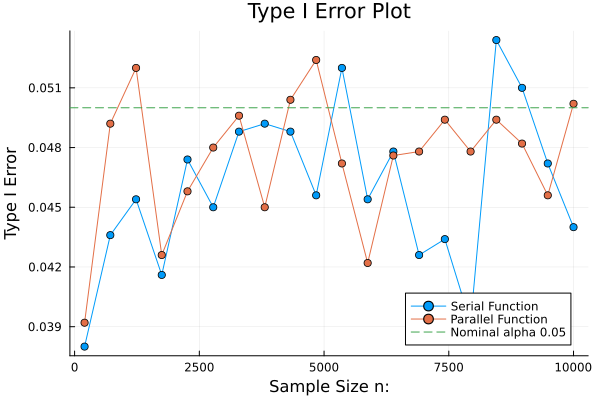

In [6]:
# 1.4(a) Plot Typo I Error 
# 不满足The plots should look the same 我需不需要set.seed to make them the same
using Plots

alpha = 0.05 
r = 5000
ns= collect(round.(Int,range(200,10000,length=20))) 
n = ns
ys_serial = serial_func.(n,n,alpha,r)
ys_parallel = parallel_func.(n,n,alpha,r)
plot(ns,ys_serial,
    label = "Serial Function",
    xlabel = "Sample Size n:",
    ylabel = "Type I Error",
    title = "Type I Error Plot",
    marker =:circle
)
plot!(
    ns,ys_parallel,
    label = "Parallel Function",
    xlabel = "Sample Size n:",
    ylabel = "Type I Error",
    title = "Type I Error Plot",
    marker =:circle
)
hline!([alpha],linestyle = :dash,label = "Nominal alpha $alpha")

Number Samples: 200 	 Serial Elapsed Time: 0.1050196 	 Parallel Elapsed Time: 0.0429164
Number Samples: 716 	 Serial Elapsed Time: 0.2965589 	 Parallel Elapsed Time: 0.1018616
Number Samples: 1232 	 Serial Elapsed Time: 0.4722385 	 Parallel Elapsed Time: 0.1574976
Number Samples: 1747 	 Serial Elapsed Time: 0.6608919 	 Parallel Elapsed Time: 0.212559
Number Samples: 2263 	 Serial Elapsed Time: 0.8512598 	 Parallel Elapsed Time: 0.4150457
Number Samples: 2779 	 Serial Elapsed Time: 1.266111 	 Parallel Elapsed Time: 0.4520073
Number Samples: 3295 	 Serial Elapsed Time: 1.432698 	 Parallel Elapsed Time: 0.4243522
Number Samples: 3811 	 Serial Elapsed Time: 1.7623299 	 Parallel Elapsed Time: 0.4808559
Number Samples: 4326 	 Serial Elapsed Time: 1.6968658 	 Parallel Elapsed Time: 0.6076793
Number Samples: 4842 	 Serial Elapsed Time: 1.9136331 	 Parallel Elapsed Time: 0.6499641
Number Samples: 5358 	 Serial Elapsed Time: 2.3968815 	 Parallel Elapsed Time: 0.6663922
Number Samples: 5874 	 Ser

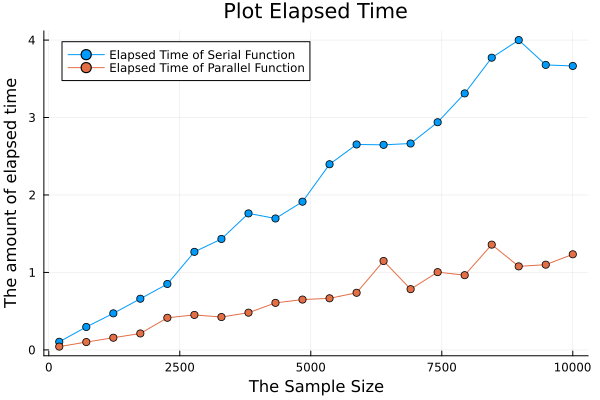

In [20]:
#1.4(b) Plot Elapsed Time
ns = collect(round.(Int,range(200,10000,length=20)))
alpha =0.05
r = 5000
time_serial=zeros(length(ns))
time_parallel = zeros(length(ns))
serial_func(100,100,alpha,r)
parallel_func(100,100,alpha,r)
for (i,n) in enumerate(ns)
    time_serial[i] = @elapsed serial_func(n,n,alpha,r)
    time_parallel[i] = @elapsed parallel_func(n,n,alpha,r)
    println("Number Samples: $n \t Serial Elapsed Time: $(time_serial[i]) \t Parallel Elapsed Time: $(time_parallel[i])")
end 
plot(ns,time_serial,
    xlabel = "The Sample Size",
    ylabel = "The amount of elapsed time",
    label = "Elapsed Time of Serial Function",
    title = "Plot Elapsed Time",
    marker =:circle
)
plot!(ns,time_parallel,
    label = "Elapsed Time of Parallel Function",
    title = "Plot Elapsed Time",
    marker =:dot
)

In [5]:
# 2.1 Create Data Write a function to generate covariates X that are in isotropic position
using LinearAlgebra
function iso_func(n,d)
    H = randn(n,d)
    F = eigen((1/n)*H'*H)
    W = F.vectors * diagm(1 ./ sqrt.(F.values)) * F.vectors'
    X = H*W
    return X 
end


iso_func (generic function with 1 method)

In [ ]:
#try 
println(iso_func(4,3))
X = iso_func(4,3) 
println(round.((1/4)* X' * X,digits = 4))


[0.06901948320331487 -1.8879718733115658 -0.06516248555548107; -1.4538431258684612 0.36264961872550894 -0.6854387219020255; 1.2979742244208305 0.3654546836033253 -1.244817780291387; 0.44366585291467664 0.4129047515529865 1.405829400341289]
[1.0 -0.0 -0.0; -0.0 1.0 0.0; -0.0 0.0 1.0]


In [ ]:
#2.2 Implementation on Jackknife Estimator:
# (a) Leave One Out Function 
function leave_out_func(X,Y,i)
    n,d = size(X)
    @assert length(Y) ==n
        X_out = X[[1:i-1;i+1:n],:]
        Y_out = Y[[1:i-1;i+1:n]]
    return X_out, Y_out
end

leave_out_func (generic function with 2 methods)

In [ ]:
#Try
X = [1 2;3 4]
Y = [3;4]
leave_out_func(X,Y,1)

([3 4], [4])

In [ ]:
# Calculate the leave_one_out OLS estimate beta_i
function ols_est_func(X,Y,i)
    X_out,Y_out = leave_out_func(X,Y,i)
    beta_i = (X_out' * X_out)\(X_out' * Y_out)

    return beta_i
end

ols_est_func (generic function with 1 method)

In [42]:
# 2. Calculate A hat, i.e. the covariance 
function covar_func(X,Y)
    n,d = size(X)
    betas = zeros(d,n)
    for i in 1:n
        betas[:,i] = ols_est_func(X,Y,i)
    end 

    beta_avg = mean(betas,dims =2)
    A_sum = zeros(d,d)
    for i in 1:n
        A = (betas[:,i]-beta_avg)*(betas[:,i]-beta_avg)'
        A_sum += A
    end
    A = (1/(n-1))*A_sum
    
    return A
end

covar_func (generic function with 3 methods)

In [8]:
# 3. Error
# 思路 A hat 就是你刚刚求的 A 是 the true one
function error_jk(X,beta_i,sigma,r)

    n,d = size(X)
    @assert length(beta_i) == d
    error_ini = zeros(r)   
    covar_true = sigma^2* inv(X'* X)

    Threads.@threads for i in 1:r
        noise = sigma * randn(n)
        Y = X * beta_i + noise
        covar_jk = covar_func(X,Y)
        norm_diff = opnorm(covar_jk - covar_true)
        error_ini[i] = norm_diff
    end
    return n*mean(error_ini)
end



error_jk (generic function with 2 methods)